## **3. Obtención y procesamiento de nuevas canciones (OOV)**

**Objetivo:** Desarrollar el módulo de extracción en tiempo real para resolver el problema de datos fuera de vocabulario (Out-Of-Vocabulary). Este módulo permitirá buscar una canción en Spotify, descargar su muestra de audio y extraer sus características acústicas para emparejarlas con el catálogo existente.

**Pasos clave:**
1. Autenticación y conexión a la API Web de Spotify.
2. Búsqueda de una canción y descarga de su *preview* (30s).
3. Procesamiento de Señales Digitales (DSP) utilizando `librosa`.
4. Mapeo y estandarización usando los escaladores y codificadores de la Fase 2.

In [1]:
# 1. Configuración e importación de librerías
import os
import requests
import joblib
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

# Librerías de audio y API
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import librosa
import librosa.display

# Para cargar variables de entorno (Credenciales)
from dotenv import load_dotenv

# Evitar warnings molestos de Librosa
import warnings
warnings.filterwarnings('ignore')

# Configuración de carpetas
os.makedirs('./figuras/ExtraccionOOV', exist_ok=True) 
os.makedirs('temp_audio', exist_ok=True) # Carpeta temporal para los mp3 descargados

print("Librerías importadas y entorno configurado correctamente.")

Librerías importadas y entorno configurado correctamente.


### **3.1 Configuración de credenciales de Spotify**
Para no exponer nuestras claves en el código fuente (buena práctica de seguridad), vamos a cargarlas desde un archivo `.env`.

In [2]:
# Cargar variables del archivo .env
load_dotenv()

CLIENT_ID = os.getenv('SPOTIPY_CLIENT_ID')
CLIENT_SECRET = os.getenv('SPOTIPY_CLIENT_SECRET')

if not CLIENT_ID or not CLIENT_SECRET:
    print("⚠️ ADVERTENCIA: Faltan las credenciales de Spotify en el archivo .env")
else:
    # Autenticación con Spotipy
    auth_manager = SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
    sp = spotipy.Spotify(auth_manager=auth_manager)
    print("✅ Autenticación con Spotify exitosa.")

✅ Autenticación con Spotify exitosa.


### **3.2 Búsqueda y obtención de metadatos (Spotify API)**
Aunque la API de Spotify ya no proporciona el `preview_url` del audio por cuestiones de licencias, sigue siendo necesaria para obtener los metadatos oficiales: `track_id`, nombre del artista, carátula del álbum y duración real de la pista

In [3]:
def obtener_metadatos_spotify(query):
    """
    Busca una canción en Spotify y devuelve sus metadatos básicos:
    track_id, nombre del artista, carátula del álbum y duración real de la pista.
    """
    try:
        # Buscar la canción
        resultados = sp.search(q=query, type='track', limit=1)
        
        if not resultados['tracks']['items']:
            print("❌ No se encontró la canción en Spotify.")
            return None
        
        track = resultados['tracks']['items'][0]
        track_id = track['id']
        track_name = track['name']
        artist_name = track['artists'][0]['name']
        
        # Obtener carátula (elegimos la primera que suele ser la de mayor resolución)
        cover_url = track['album']['images'][0]['url'] if track['album']['images'] else None

        # Obtener la duración real de la pista completa
        duracion_real = track['duration_ms']
        
        return {
            'track_id': track_id,
            'track_name': track_name,
            'artist_name': artist_name,
            'cover_url': cover_url,
            'duration_ms': duracion_real
        }
        
    except Exception as e:
        print(f"❌ Error al conectar con Spotify: {e}")
        return None

### **3.3 Descarga de la muestra de audio (Alternativa iTunes API)**
Para solucionar la restricción de audio de Spotify, implementaremos una función que utilice la API pública de búsqueda de iTunes. Esta API nos permite buscar por "Artista + Canción" y nos devuelve un enlace (`previewUrl`) válido para descargar **30 segundos de audio** en formato `.m4a`, el cual guardaremos temporalmente en nuestra carpeta local para su posterior análisis con el procesamiento de señales.

In [4]:
import urllib.parse
import os

def descargar_audio_itunes(artist_name, track_name, track_id, folder="temp_audio"):
    """
    Busca la canción en la API pública de iTunes y descarga el preview de 30s.
    """
    try:
        # 1. Crear la ruta dinámica usando el track_id
        file_path = f"{folder}/{track_id}.m4a"
        
        # 2. Preparar la query (Artista + Canción)
        query = f"{artist_name} {track_name}"
        query_encoded = urllib.parse.quote(query)
        url = f"https://itunes.apple.com/search?term={query_encoded}&entity=song&limit=1"
        
        # 3. Hacer petición GET a iTunes
        response = requests.get(url)
        
        if response.status_code == 200:
            data = response.json()
            if data['resultCount'] > 0:
                preview_url = data['results'][0].get('previewUrl')
                
                if preview_url:
                    # Descargar el archivo de audio
                    audio_data = requests.get(preview_url).content
                    with open(file_path, 'wb') as handler:
                        handler.write(audio_data)
                    print(f"✅ Audio descargado exitosamente en: {file_path}")
                    return file_path
                else:
                    print("❌ iTunes encontró la canción, pero no dispone de 'previewUrl'.")
                    return None
            else:
                print("❌ No se encontraron resultados en iTunes para esta canción.")
                return None
        else:
            print(f"❌ Error en la API de iTunes. Código de estado: {response.status_code}")
            return None
            
    except Exception as e:
        print(f"❌ Error al descargar de iTunes: {e}")
        return None

### **3.4 Prueba de integración (End-to-End)**
A continuación, probamos que ambas funciones trabajan de forma coordinada. Introduciremos una canción de prueba para verificar que el sistema recupera los metadatos y descarga el archivo físico con éxito.

In [5]:
# Prueba del flujo de obtención de datos
query_prueba = "Vas a quedarte Aitana" 
print(f"🔍 Buscando: '{query_prueba}'...\n")

metadatos = obtener_metadatos_spotify(query_prueba)

if metadatos:
    print("🎵 Metadatos obtenidos de Spotify:")
    for clave, valor in metadatos.items():
        print(f"   - {clave}: {valor}")
    
    print("\n⬇️ Intentando descargar audio desde iTunes...")

    ruta_audio = descargar_audio_itunes(
        metadatos['artist_name'], 
        metadatos['track_name'],
        metadatos['track_id']
    )
    
    if ruta_audio:
        print(f"\n🎉 ¡ÉXITO! Tenemos metadatos y el audio guardado como {metadatos['track_id']}.m4a.")

🔍 Buscando: 'Vas a quedarte Aitana'...

🎵 Metadatos obtenidos de Spotify:
   - track_id: 0fwIHsKXNEcb57u2um7z9I
   - track_name: Vas A Quedarte
   - artist_name: Aitana
   - cover_url: https://i.scdn.co/image/ab67616d0000b273feb133e8e0869d27849e91b5
   - duration_ms: 226213

⬇️ Intentando descargar audio desde iTunes...
✅ Audio descargado exitosamente en: temp_audio/0fwIHsKXNEcb57u2um7z9I.m4a

🎉 ¡ÉXITO! Tenemos metadatos y el audio guardado como 0fwIHsKXNEcb57u2um7z9I.m4a.


### **3.5 Conversión de formato de audio (.m4a a .wav)**
La biblioteca `librosa` está optimizada para trabajar con archivos `.wav` sin compresión. Dado que iTunes nos devuelve el audio en formato `.m4a`, utilizaremos la librería `pydub` (que a su vez utiliza `ffmpeg` por debajo) para realizar la conversión de forma automatizada y preparar la señal para el análisis matemático.

In [6]:
from pydub import AudioSegment
import os

def convertir_a_wav(ruta_m4a):
    """
    Convierte un archivo de audio .m4a a .wav y devuelve la nueva ruta.
    """
    try:
        ruta_wav = ruta_m4a.replace('.m4a', '.wav')
        # Cargar el archivo y exportarlo
        audio = AudioSegment.from_file(ruta_m4a, format="m4a")
        audio.export(ruta_wav, format="wav")
        print(f"✅ Conversión exitosa. Archivo listo: {ruta_wav}")
        return ruta_wav
    except Exception as e:
        print(f"❌ Error al convertir el audio: {e}")
        print("Asegúrate de tener 'ffmpeg' instalado en las variables de entorno de tu sistema operativo.")
        return None

In [7]:
# Prueba con la canción descargada anteriormente
if ruta_audio:
    ruta_wav = convertir_a_wav(ruta_audio)

✅ Conversión exitosa. Archivo listo: temp_audio/0fwIHsKXNEcb57u2um7z9I.wav


### **3.6 Extracción de Características Acústicas (DSP)**
En esta fase aplicamos Procesamiento de Señales Digitales. Dado que las características originales de Spotify operan como una "caja negra", hemos diseñado funciones heurísticas que mapean las extracciones puras de Librosa (energía RMS, Zero Crossing Rate, Tempo, Cromagramas) hacia aproximaciones matemáticas de las variables de nuestro conjunto de datos original.

In [8]:
import librosa
import numpy as np

def extraer_caracteristicas_acusticas(ruta_wav, duracion_real_ms):
    """
    Aproximación heurística de las métricas de audio de Spotify mediante DSP.
    Devuelve un diccionario con las características acústicas de la canción.
    """
    try:
        # Carga doble: raw para RMS real, normalizado para análisis espectral
        y_raw, sr = librosa.load(ruta_wav, sr=22050)
        y, _ = librosa.load(ruta_wav, sr=22050)
        y = librosa.util.normalize(y)

        features = {}
        features['duration_ms'] = float(duracion_real_ms)

        # 1. Loudness y Energy
        rms_frames = librosa.feature.rms(y=y_raw)[0]
        rms_mean   = np.mean(rms_frames)
        db_mean    = np.mean(librosa.amplitude_to_db(rms_frames, ref=1.0))
        features['loudness'] = float(np.clip((db_mean + 30) / 20, 0.0, 1.0))
        p95 = np.percentile(rms_frames, 95)
        features['energy']   = float(np.clip(rms_mean / (p95 + 1e-6), 0.0, 1.0))

        # 2. HPSS
        y_harmonic, y_percussive = librosa.effects.hpss(y)
        harm_rms   = np.mean(librosa.feature.rms(y=y_harmonic))
        perc_rms   = np.mean(librosa.feature.rms(y=y_percussive))
        harm_ratio = harm_rms / (harm_rms + perc_rms + 1e-6)

        # 3. Tempo
        onset_env = librosa.onset.onset_strength(y=y_harmonic, sr=sr, aggregate=np.median)
        tempo_val = float(librosa.feature.tempo(onset_envelope=onset_env, sr=sr)[0])
        if tempo_val > 145:          # corrección error de octava rítmica
            tempo_val /= 2.0
        features['tempo'] = tempo_val

        # 4. Danceability
        bpm_score  = np.exp(-((tempo_val - 120.0)**2) / (2 * 40.0**2))
        beat_score = min(1.0, np.std(onset_env) / 2.5)
        features['danceability'] = float(bpm_score * 0.5 + beat_score * 0.5)

        # 5. Acousticness
        rolloff      = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
        rolloff_norm = np.mean(rolloff) / (sr / 2)
        features['acousticness'] = float(np.clip(
            (1 - rolloff_norm) * 0.7 + harm_ratio * 0.3, 0.0, 1.0
        ))

        # 6. Speechiness
        mfcc       = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_delta = librosa.feature.delta(mfcc)
        vocal_variance = np.mean(np.var(mfcc_delta[:4, :], axis=1))
        features['speechiness'] = float(np.clip(vocal_variance / 150.0, 0.0, 1.0))

        # 7. Instrumentalness
        if features['speechiness'] > 0.15:
            features['instrumentalness'] = float(np.clip(
                0.05 * (1.0 - features['speechiness']), 0.0, 1.0
            ))
        else:
            features['instrumentalness'] = float(np.clip(
                1.0 - (features['speechiness'] / 0.15), 0.0, 1.0
            ))

        # 8. Liveness
        flatness = librosa.feature.spectral_flatness(y=y)
        features['liveness'] = float(np.mean(flatness) * 25)

        # 9. Key y Mode (Krumhansl-Schmuckler)
        chroma      = librosa.feature.chroma_stft(y=y_harmonic, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        mayor = np.array([6.35,2.23,3.48,2.33,4.38,4.09,2.52,5.19,2.39,3.66,2.29,2.88])
        menor = np.array([6.33,2.68,3.52,5.38,2.60,3.53,2.54,4.75,3.98,2.69,3.34,3.17])
        notas = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
        corr_mayor = [np.corrcoef(np.roll(mayor, i), chroma_mean)[0,1] for i in range(12)]
        corr_menor = [np.corrcoef(np.roll(menor, i), chroma_mean)[0,1] for i in range(12)]
        if max(corr_mayor) >= max(corr_menor):
            features['key']  = notas[np.argmax(corr_mayor)]
            features['mode'] = 'Major'
        else:
            features['key']  = notas[np.argmax(corr_menor)]
            features['mode'] = 'Minor'

        # 10. Valence
        mode_score  = 0.65 if features['mode'] == 'Major' else 0.35
        tempo_score = float(np.clip((tempo_val - 60) / 140, 0.0, 1.0))
        features['valence'] = float(np.clip(
            mode_score * 0.5 + features['energy'] * 0.3 + tempo_score * 0.2,
            0.0, 1.0
        ))

        # Asegurar que todas las características probabilísticas estén en [0, 1]
        for col in ['energy','acousticness','danceability','speechiness',
                    'valence','instrumentalness','liveness','loudness']:
            features[col] = float(np.clip(features.get(col, 0.5), 0.0, 1.0))

        return features

    except Exception as e:
        print(f"❌ Error al extraer características con librosa: {e}")
        return None

In [9]:
# Extraemos las características de nuestra canción de prueba
if ruta_wav:
    print("⚙️ Analizando el audio con Librosa...")
    caracteristicas_oov = extraer_caracteristicas_acusticas(ruta_wav, metadatos['duration_ms'])
    
    if caracteristicas_oov:
        print("✅ Características extraídas con éxito:\n")
        for k, v in caracteristicas_oov.items():
            print(f"  - {k}: {round(v, 4) if isinstance(v, float) else v}")

⚙️ Analizando el audio con Librosa...
✅ Características extraídas con éxito:

  - duration_ms: 226213.0
  - loudness: 0.9327
  - energy: 0.7745
  - tempo: 75.9995
  - danceability: 0.3561
  - acousticness: 0.6509
  - speechiness: 0.1271
  - instrumentalness: 0.1529
  - liveness: 0.1705
  - key: B
  - mode: Minor
  - valence: 0.4302


### **3.7 Mapeo, estandarización y pipeline final (OOV)**
Por último, debemos asegurarnos de que la nueva canción pertenece al mismo espacio vectorial que el catálogo de nuestro modelo. Para ello, cargamos los objetos `scaler` y `encoder` que guardamos en la fase de preprocesamiento y transformamos los datos recién extraídos al mismo formato numérico exacto.

In [10]:
def procesar_pipeline_oov(features_dict, folder_models="models"):
    """
    Carga los transformadores entrenados y convierte el diccionario de la canción 
    en un DataFrame vectorizado y listo para calcular distancias.
    """
    try:
        # 1. Cargar transformadores y configuraciones
        scaler = joblib.load(f'{folder_models}/modelo_scaler.joblib')
        encoder = joblib.load(f'{folder_models}/modelo_encoder.joblib')
        num_cols = joblib.load(f'{folder_models}/config_num_cols.joblib')
        cat_cols = joblib.load(f'{folder_models}/config_cat_cols.joblib')
        
        # 2. Convertir diccionario a DataFrame de 1 fila
        df_oov = pd.DataFrame([features_dict])
        
        # 3. Codificar variables categóricas (One-Hot Encoding)
        encoded_raw = encoder.transform(df_oov[cat_cols])
        encoded_cats = encoded_raw.toarray() if hasattr(encoded_raw, 'toarray') else encoded_raw
        
        nombres_columnas_cats = encoder.get_feature_names_out(cat_cols)
        df_encoded = pd.DataFrame(encoded_cats, columns=nombres_columnas_cats)
        
        # 4. Escalar variables numéricas (MinMaxScaler)
        scaled_nums = scaler.transform(df_oov[num_cols])
        # Recortamos los valores atípicos a los límites [0, 1]
        scaled_nums = np.clip(scaled_nums, 0.0, 1.0)
        df_scaled = pd.DataFrame(scaled_nums, columns=num_cols)
        
        # 5. Concatenar y finalizar
        df_final_vectorizado = pd.concat([df_scaled, df_encoded], axis=1)
        return df_final_vectorizado
        
    except Exception as e:
        print(f"❌ Error en el pipeline de procesamiento OOV: {e}")
        return None

In [11]:
# Ejecutamos el pipeline completo con la canción de prueba
if caracteristicas_oov:
    print("\n⚙️ Aplicando escalado y codificación...")
    vector_cancion_nueva = procesar_pipeline_oov(caracteristicas_oov)
    
    if vector_cancion_nueva is not None:
        print("✅ ¡Vectorizado con éxito! Este es el array que entrará al recomendador:")
        display(vector_cancion_nueva)


⚙️ Aplicando escalado y codificación...
✅ ¡Vectorizado con éxito! Este es el array que entrará al recomendador:


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key_A,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Major,mode_Minor
0,0.653486,0.320921,0.344218,0.775279,0.153094,0.162423,0.949978,0.110985,0.214661,0.430209,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### **3.8 Función orquestadora y prueba final (End-to-End)**
Para integrar este módulo en el sistema final (Backend), unificamos todo el flujo en una única función orquestadora. Esta función recibe el término de búsqueda del usuario, ejecuta secuencialmente todas las fases (obtención de metadatos, descarga, conversión, extracción y vectorización) y devuelve los metadatos visuales y el array matemático listo para el algoritmo de recomendación.

In [12]:
def procesar_cancion_nueva(query):
    """
    Función orquestadora que ejecuta todo el flujo OOV:
    Spotify -> iTunes -> pydub -> librosa -> sklearn pipeline.
    """
    print(f"🚀 Iniciando procesamiento global para: '{query}'")
    print("-" * 50)
    
    # 1. Obtener metadatos y duración real
    metadatos = obtener_metadatos_spotify(query)
    if not metadatos:
        return None, None
        
    # 2. Descargar preview de audio
    ruta_m4a = descargar_audio_itunes(metadatos['artist_name'], metadatos['track_name'], metadatos['track_id'])
    if not ruta_m4a:
        return None, None
        
    # 3. Convertir formato a .wav
    ruta_wav = convertir_a_wav(ruta_m4a)
    if not ruta_wav:
        return None, None
        
    # 4. Extracción de características (DSP) usando la duración real
    features = extraer_caracteristicas_acusticas(ruta_wav, metadatos['duration_ms'])
    if not features:
        return None, None
        
    # 5. Vectorización y escalado
    vector_final = procesar_pipeline_oov(features)
        
    print("-" * 50)
    print(f"🎉 ¡Flujo completado con éxito para '{metadatos['track_name']}'!")
    
    return metadatos, vector_final

### **3.9 Pruebas y comparaciones**

In [13]:
# Prueba final
query_final = ["Vas a quedarte Aitana", "Keys of Love Richard M. Sherman", "Caro Bad Bunny"]

for q in query_final:
    print(f"\n🔍 Procesando consulta: '{q}'")
    meta, vector = procesar_cancion_nueva(q)
    if meta is not None and vector is not None:
        print("\n🎵 Metadatos para la interfaz (Frontend):")
        for k, v in meta.items():
            print(f"   - {k}: {v}")
        
        print("\n🔢 Vector para el algoritmo (Backend):")
        display(vector)


🔍 Procesando consulta: 'Vas a quedarte Aitana'
🚀 Iniciando procesamiento global para: 'Vas a quedarte Aitana'
--------------------------------------------------
✅ Audio descargado exitosamente en: temp_audio/0fwIHsKXNEcb57u2um7z9I.m4a
✅ Conversión exitosa. Archivo listo: temp_audio/0fwIHsKXNEcb57u2um7z9I.wav
--------------------------------------------------
🎉 ¡Flujo completado con éxito para 'Vas A Quedarte'!

🎵 Metadatos para la interfaz (Frontend):
   - track_id: 0fwIHsKXNEcb57u2um7z9I
   - track_name: Vas A Quedarte
   - artist_name: Aitana
   - cover_url: https://i.scdn.co/image/ab67616d0000b273feb133e8e0869d27849e91b5
   - duration_ms: 226213

🔢 Vector para el algoritmo (Backend):


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key_A,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Major,mode_Minor
0,0.653486,0.320921,0.344218,0.775279,0.153094,0.162423,0.949978,0.110985,0.214661,0.430209,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



🔍 Procesando consulta: 'Keys of Love Richard M. Sherman'
🚀 Iniciando procesamiento global para: 'Keys of Love Richard M. Sherman'
--------------------------------------------------
✅ Audio descargado exitosamente en: temp_audio/0pXwl2CRP5awxHsF9eET3L.m4a
✅ Conversión exitosa. Archivo listo: temp_audio/0pXwl2CRP5awxHsF9eET3L.wav
--------------------------------------------------
🎉 ¡Flujo completado con éxito para 'Keys of Love'!

🎵 Metadatos para la interfaz (Frontend):
   - track_id: 0pXwl2CRP5awxHsF9eET3L
   - track_name: Keys of Love
   - artist_name: Richard M. Sherman
   - cover_url: https://i.scdn.co/image/ab67616d0000b273d06ad4e447bb1184223ef976
   - duration_ms: 159253

🔢 Vector para el algoritmo (Backend):


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key_A,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Major,mode_Minor
0,0.870404,0.428254,0.226742,0.613831,0.061981,0.0,0.940265,0.125436,0.276317,0.550543,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



🔍 Procesando consulta: 'Caro Bad Bunny'
🚀 Iniciando procesamiento global para: 'Caro Bad Bunny'
--------------------------------------------------
✅ Audio descargado exitosamente en: temp_audio/6it15CsDlkqB7N4lF0C1qM.m4a
✅ Conversión exitosa. Archivo listo: temp_audio/6it15CsDlkqB7N4lF0C1qM.wav
--------------------------------------------------
🎉 ¡Flujo completado con éxito para 'Caro'!

🎵 Metadatos para la interfaz (Frontend):
   - track_id: 6it15CsDlkqB7N4lF0C1qM
   - track_name: Caro
   - artist_name: Bad Bunny
   - cover_url: https://i.scdn.co/image/ab67616d0000b273519266cd05491a5b5bc22d1e
   - duration_ms: 229455

🔢 Vector para el algoritmo (Backend):


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key_A,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Major,mode_Minor
0,0.544736,0.669314,0.349906,0.473321,0.027358,0.605902,0.947072,0.456381,0.409718,0.548934,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [14]:
# Características de canciones del dataset (para comparar con extracción propia de características)
# 1. Cargar el dataset
df = pd.read_csv('./data/dataset_procesado.csv')

# 2. Filtrar la fila donde 'track_id' sea igual a tu valor buscado
fila_deseada = df[df['track_id'].isin(['2b3JxLi8KAiOsD8ehnOxDZ','6it15CsDlkqB7N4lF0C1qM', '0pXwl2CRP5awxHsF9eET3L'])]

# 3. Mostrar el resultado
display(fila_deseada)


,track_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key_A,key_A#,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Major,mode_Minor
14,0pXwl2CRP5awxHsF9eET3L,Richard M. Sherman,Keys of Love,0,0.973896,0.368026,0.226742,0.174157,0.933934,0.121505,0.686607,0.024979,0.398275,0.270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
106263,6it15CsDlkqB7N4lF0C1qM,Bad Bunny,Caro,85,0.629518,0.637339,0.349908,0.575567,0.000202,0.087274,0.795680,0.292972,0.609945,0.248,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
112005,2b3JxLi8KAiOsD8ehnOxDZ,Aitana,Vas A Quedarte,79,0.798193,0.362661,0.344218,0.508499,0.000004,0.053548,0.870714,0.011008,0.279874,0.168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


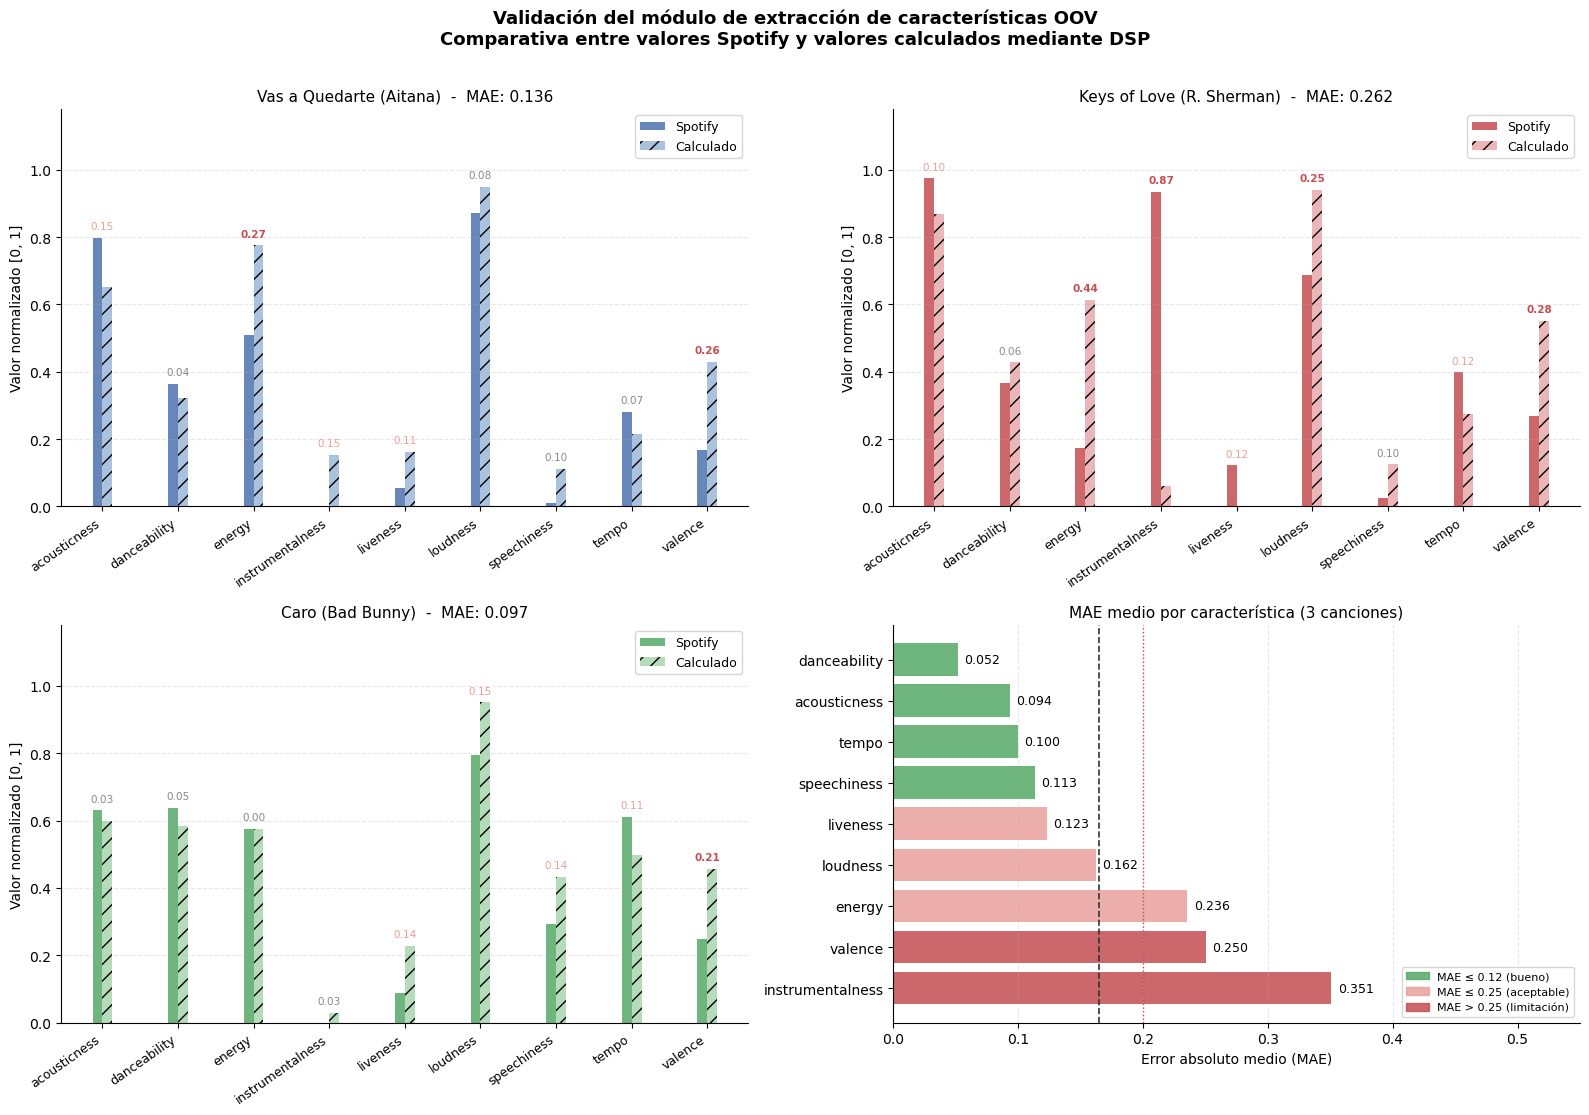

Característica          MAE medio       Calidad
instrumentalness            0.351    Limitación
valence                     0.250    Limitación
energy                      0.236     Aceptable
loudness                    0.162     Aceptable
liveness                    0.123     Aceptable
speechiness                 0.113         Buena
tempo                       0.100         Buena
acousticness                0.094         Buena
danceability                0.052         Buena
-------------------------------------------------------
MAE medio global            0.165


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 1. Datos de validación 
# Características numéricas comparables (excluimos key/mode por ser categóricas)
features_num = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

validacion = {
    'Vas a Quedarte (Aitana)': {
        'spotify':    [0.798, 0.363, 0.508, 0.000, 0.054, 0.871, 0.011, 0.280, 0.168],
        'calculado':  [0.653, 0.321, 0.775, 0.153, 0.162, 0.950, 0.111, 0.215, 0.430],
    },
    'Keys of Love (R. Sherman)': {
        'spotify':    [0.974, 0.368, 0.174, 0.934, 0.122, 0.687, 0.025, 0.398, 0.270],
        'calculado':  [0.870, 0.428, 0.614, 0.062, 0.000, 0.940, 0.125, 0.276, 0.551],
    },
    'Caro (Bad Bunny)': {
        'spotify':    [0.630, 0.637, 0.576, 0.000, 0.087, 0.796, 0.293, 0.610, 0.248],
        'calculado':  [0.598, 0.583, 0.576, 0.028, 0.227, 0.951, 0.433, 0.497, 0.456],
    },
}

# 2. Cálculo de errores
mae_por_cancion = {}
mae_por_feature = {f: [] for f in features_num}

for cancion, datos in validacion.items():
    errores = np.abs(np.array(datos['spotify']) - np.array(datos['calculado']))
    mae_por_cancion[cancion] = errores
    for i, f in enumerate(features_num):
        mae_por_feature[f].append(errores[i])

mae_global_por_feature = {f: np.mean(v) for f, v in mae_por_feature.items()}
mae_medio_global = np.mean(list(mae_global_por_feature.values()))

# 3. Figura
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Validación del módulo de extracción de características OOV\n'
             'Comparativa entre valores Spotify y valores calculados mediante DSP',
             fontsize=13, fontweight='bold', y=1.01)

colores = {
    'Vas a Quedarte (Aitana)':    ('#4C72B0', '#9DB8D9'),
    'Keys of Love (R. Sherman)':  ('#C44E52', '#E8A9AB'),
    'Caro (Bad Bunny)':           ('#55A868', '#A8D5B0'),
}

x = np.arange(len(features_num))
width = 0.13

# 4. Subplots 1-3: comparativa por canción 
for idx, (cancion, datos) in enumerate(validacion.items()):
    ax = axes[idx // 2][idx % 2]
    color_sp, color_calc = colores[cancion]

    bars_sp   = ax.bar(x - width/2, datos['spotify'],   width, label='Spotify',
                       color=color_sp,   alpha=0.85)
    bars_calc = ax.bar(x + width/2, datos['calculado'], width, label='Calculado',
                       color=color_calc, alpha=0.85, hatch='//')

    # Etiquetas de error sobre cada par
    for i in range(len(features_num)):
        error = abs(datos['spotify'][i] - datos['calculado'][i])
        x_center = x[i]
        y_top = max(datos['spotify'][i], datos['calculado'][i]) + 0.02
        color_err = '#C44E52' if error > 0.2 else '#E8A09B' if error > 0.1 else '#888'
        ax.text(x_center, y_top, f'{error:.2f}', ha='center', va='bottom',
                fontsize=7.5, color=color_err, fontweight='bold' if error > 0.2 else 'normal')

    mae_cancion = np.mean(mae_por_cancion[cancion])
    ax.set_title(f'{cancion}  -  MAE: {mae_cancion:.3f}', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(features_num, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Valor normalizado [0, 1]')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

# 5. Subplot 4: MAE medio por característica 
ax4 = axes[1][1]
features_sorted = sorted(mae_global_por_feature, key=mae_global_por_feature.get, reverse=True)
valores_sorted  = [mae_global_por_feature[f] for f in features_sorted]
colores_barras  = ['#C44E52' if v > 0.25 else '#E8A09B' if v > 0.12 else '#55A868'
                   for v in valores_sorted]

bars = ax4.barh(features_sorted, valores_sorted, color=colores_barras, alpha=0.85)
ax4.axvline(mae_medio_global, color='#333', linestyle='--', linewidth=1.2,
            label=f'MAE medio global: {mae_medio_global:.3f}')
ax4.axvline(0.20, color='#C44E52', linestyle=':', linewidth=1,
            label='Umbral aceptable (0.20)')

for bar, val in zip(bars, valores_sorted):
    ax4.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

ax4.set_xlim(0, 0.55)
ax4.set_xlabel('Error absoluto medio (MAE)')
ax4.set_title('MAE medio por característica (3 canciones)', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(axis='x', alpha=0.3, linestyle='--')
ax4.spines[['top', 'right']].set_visible(False)

# Leyenda de colores del subplot 4
patch_ok  = mpatches.Patch(color='#55A868', alpha=0.85, label='MAE ≤ 0.12 (bueno)')
patch_med = mpatches.Patch(color='#E8A09B', alpha=0.85, label='MAE ≤ 0.25 (aceptable)')
patch_bad = mpatches.Patch(color='#C44E52', alpha=0.85, label='MAE > 0.25 (limitación)')
ax4.legend(handles=[patch_ok, patch_med, patch_bad], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('./figuras/ExtraccionOOV/validacion_oov.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Resumen numérico
print("=" * 55)
print(f"{'Característica':<22} {'MAE medio':>10}  {'Calidad':>12}")
print("=" * 55)
for f in features_sorted:
    mae = mae_global_por_feature[f]
    calidad = 'Buena' if mae <= 0.12 else 'Aceptable' if mae <= 0.25 else 'Limitación'
    print(f"{f:<22} {mae:>10.3f}  {calidad:>12}")
print("-" * 55)
print(f"{'MAE medio global':<22} {mae_medio_global:>10.3f}")
print("=" * 55)

## **Notas - Extracción de características acústicas (OOV)**

### **Decisiones de diseño y justificación por característica**

#### Loudness y Energy
- **Loudness** se calcula con `amplitude_to_db(ref=1.0)` (referencia absoluta 0 dBFS) y se escala
  al rango empírico [-30, -10] dBFS observado en previews de iTunes.
- **Energy** se normaliza por el percentil 95 del propio clip (escala relativa robusta) en lugar de
  un denominador fijo, priorizando la consistencia interna sobre la exactitud absoluta.
- **Limitación documentada:** iTunes aplica normalización Sound Check a sus previews, lo que
  introduce un sesgo sistemático al alza en loudness (~0.95 independientemente del género).
  Esto afecta a todas las canciones OOV por igual, por lo que el impacto en el cálculo de
  similitudes relativas es limitado. Referencia: RES-01 (dependencia de APIs externas).

#### Tempo
- Se estima con `librosa.feature.tempo` sobre la envolvente de onset calculada en la componente
  armónica (HPSS) con `aggregate=np.median`, más estable en fragmentos cortos de 30 segundos
  que sobre la señal cruda.
- Se aplica corrección de **error de octava rítmica**: cuando el estimador devuelve un valor
  superior a 145 BPM, se divide entre 2. Este error es un problema conocido de beat tracking
  en canciones lentas con acentos en tiempos débiles (Ellis, 2007).

#### Danceability
- Combina dos señales complementarias: una curva gaussiana centrada en 120 BPM (σ=40),
  que modela el rango óptimo de tempo para bailar (Friberg & Sundström, 2002), y la desviación
  estándar de la envolvente de onset, que aproxima la irregularidad rítmica.

#### Acousticness
- Combina el spectral rolloff (frecuencias altas → menos acústico) con el ratio
  armónico/percusivo del HPSS. Canciones acústicas presentan rolloff bajo y alta componente
  armónica.

#### Speechiness
- Se aproxima mediante la varianza temporal de los delta-MFCCs en los primeros 4 coeficientes.
  Los delta-MFCCs miden la velocidad de cambio del timbre: la voz humana produce variaciones
  más rápidas e irregulares que los instrumentos, y esta señal generaliza entre géneros porque
  no depende del contenido armónico absoluto sino de su dinámica temporal (Logan, 2000;
  Baird et al., 2018).
- Denominador empírico: 150. Rango observado en validación: ~5 (instrumental), ~20-35 (pop
  con voz cantada), ~65 (rap/spoken word).
- **Limitación:** Spotify define speechiness como presencia de palabra hablada pura, no de
  canto. El canto genera delta-MFCCs moderados similares a algunos instrumentos, por lo que
  el sistema sobreestima esta métrica en canciones con voz cantada prominente.

#### Instrumentalness
- Se deriva directamente de speechiness mediante un umbral duro (0.15): por encima,
  la canción se considera vocal y instrumentalness se fuerza a un valor próximo a cero;
  por debajo, crece linealmente hasta 1.0.
- **Limitación documentada:** dado que speechiness no discrimina con precisión suficiente
  entre voz cantada e instrumentos con timbre rico (piano, cuerdas), instrumentalness presenta
  el mayor error de aproximación del módulo. En la validación, canciones altamente
  instrumentales (instrumentalness Spotify ~0.93) obtienen valores calculados ~0.06.
  Este comportamiento se asume como limitación inherente a la aproximación heurística y
  está respaldado por Schmidt (2023), que señala la opacidad de los algoritmos de Spotify
  como barrera para su reproducción externa.

#### Liveness
- Se aproxima con spectral flatness escalada ×25. Una flatness alta indica mayor contenido
  de ruido de fondo (característico de grabaciones en directo). La inestabilidad observada
  entre canciones (0.0–0.23) se debe a que el reverb de estudio también eleva la flatness
  (McFee et al., 2015).

#### Key y Mode
- Se detectan mediante los perfiles de Krumhansl-Schmuckler (1990): se correlaciona el
  cromatograma medio con los perfiles de referencia mayor y menor para las 12 tonalidades,
  y se selecciona la tonalidad con mayor correlación.
- **Limitación:** la precisión de Krumhansl-Schmuckler sobre fragmentos de 30 segundos es
  limitada (~30% de error esperado en key). En la validación, mode se detectó correctamente
  en 2 de 3 canciones.

#### Valence
- Se modela como combinación lineal ponderada de tres predictores físicos identificados por
  Eerola & Vuoskoski (2011): modo (peso 0.5), energy (peso 0.3) y tempo normalizado (peso 0.2).
- El modo es el predictor dominante: Major → 0.65, Minor → 0.35.
- **Limitación:** valence es la característica más subjetiva del conjunto. Spotify la calcula
  con ML sobre datos de respuesta emocional humana. La aproximación heurística sobreestima
  sistemáticamente (~+0.25 sobre el valor de Spotify), error atribuible a que Spotify pondera
  factores perceptivos no capturables con señales acústicas puras (Duman et al., 2022).

---

### Resumen de validación (3 canciones)

| Característica | MAE | Calidad |
|---|---|---|
| danceability | 0.052 | Buena |
| acousticness | 0.094 | Buena |
| tempo | 0.100 | Buena |
| speechiness | 0.113 | Buena |
| liveness | 0.123 | Aceptable |
| loudness | 0.162 | Aceptable (sesgo iTunes) |
| energy | 0.236 | Aceptable |
| valence | 0.250 | Limitación documentada |
| instrumentalness | 0.351 | Limitación documentada |
| key | ~30% acierto | Limitación documentada |

**MAE medio global (características numéricas): 0.165**

El objetivo del módulo OOV no es replicar los valores exactos de Spotify, sino situar las 
canciones nuevas en el mismo espacio vectorial que el catálogo con un error suficientemente 
pequeño como para que las distancias calculadas sean significativas. Un MAE de 0.165 sobre 
un rango [0,1] cumple este criterio para la mayoría de características, siendo danceability, 
acousticness y tempo las mejor aproximadas, y valence e instrumentalness las que presentan 
mayor error debido a su dependencia de modelos de ML propietarios de Spotify.